#### <h1 style="color: #ab9bde;">INSTALL & IMPORT LIBRARIES</h1>

In [5]:
pip install numpy pandas matplotlib seaborn scipy scikit-learn jupyter ipykernel openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 7.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 11.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 24.8 MB/s eta 0:00:0000:01

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use('default')
sns.set_theme(style="whitegrid")

# Statistics
from scipy import stats

# Date & Time
from datetime import datetime

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Warning Control
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


### <h2 style="color: #ab9bde;">Load Dataset</h2>

In [3]:
df = pd.read_csv("/Users/laxmigupte/Desktop/Hotel-Revenue-Operations/data/hotel_bookings.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


<div style="color:#ab9bde;">

## <h3>Initial Data Audit:</h3>

Before analysis, inspect:

- Dataset dimensions
- Column names
- Data types
- Missing values
- Duplicate records

This helps assess overall data quality.

</div>

In [3]:
# Dataset Shape

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 119,390
Columns : 32


In [5]:
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,107.00,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,0.00,0,FB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,303.00,NaN,0,Transient,103.00,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,0.00,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,82.00,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,0.00,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,D,D,0,No Deposit,15.00,NaN,0,Transient,105.50,0,0,Canceled,2015-04-22


In [4]:
# Column Names

df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

In [5]:
# Data Types & Missing Values Overview

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [6]:
# Statistical Summary

df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.00,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.10,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.40,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.00,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00


In [7]:
# Statistical Summary Including Categoricals

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.00,NaN,NaN,NaN,0.37,0.48,0.00,0.00,0.00,1.00,1.00
lead_time,119390.00,NaN,NaN,NaN,104.01,106.86,0.00,18.00,69.00,160.00,737.00
arrival_date_year,119390.00,NaN,NaN,NaN,2016.16,0.71,2015.00,2016.00,2016.00,2017.00,2017.00
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.00,NaN,NaN,NaN,27.17,13.61,1.00,16.00,28.00,38.00,53.00
arrival_date_day_of_month,119390.00,NaN,NaN,NaN,15.80,8.78,1.00,8.00,16.00,23.00,31.00
stays_in_weekend_nights,119390.00,NaN,NaN,NaN,0.93,1.00,0.00,0.00,1.00,2.00,19.00
stays_in_week_nights,119390.00,NaN,NaN,NaN,2.50,1.91,0.00,1.00,2.00,3.00,50.00
adults,119390.00,NaN,NaN,NaN,1.86,0.58,0.00,2.00,2.00,2.00,55.00


In [8]:
# Missing Value Analysis

missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": round((df.isnull().sum() / len(df)) * 100, 2)
})

missing_values = (
    missing_values
    .sort_values("Missing Count", ascending=False)
)

missing_values[missing_values["Missing Count"] > 0]

,Missing Count,Missing %
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


In [9]:
# Duplicate Record Analysis

duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates:,}")

Duplicate Records: 31,994


In [10]:
# Drop duplicates
df = df.drop_duplicates()

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 87,396
Columns : 32


<div style="color:#ab9bde;">

## <h3>Target Variable:</h3>

The primary objective of this project is to predict booking cancellations.

Target Feature:

- is_canceled

Interpretation:

| Value | Meaning |
|----------|----------|
| 0 | Booking Completed |
| 1 | Booking Cancelled |


</div>

In [11]:
df["is_canceled"].value_counts()

is_canceled
0    63371
1    24025
Name: count, dtype: int64

In [12]:
(
    df["is_canceled"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

is_canceled
0   72.51
1   27.49
Name: proportion, dtype: float64

### <h2 style="color: #ab9bde;">Categorical Feature Distribution</h2>

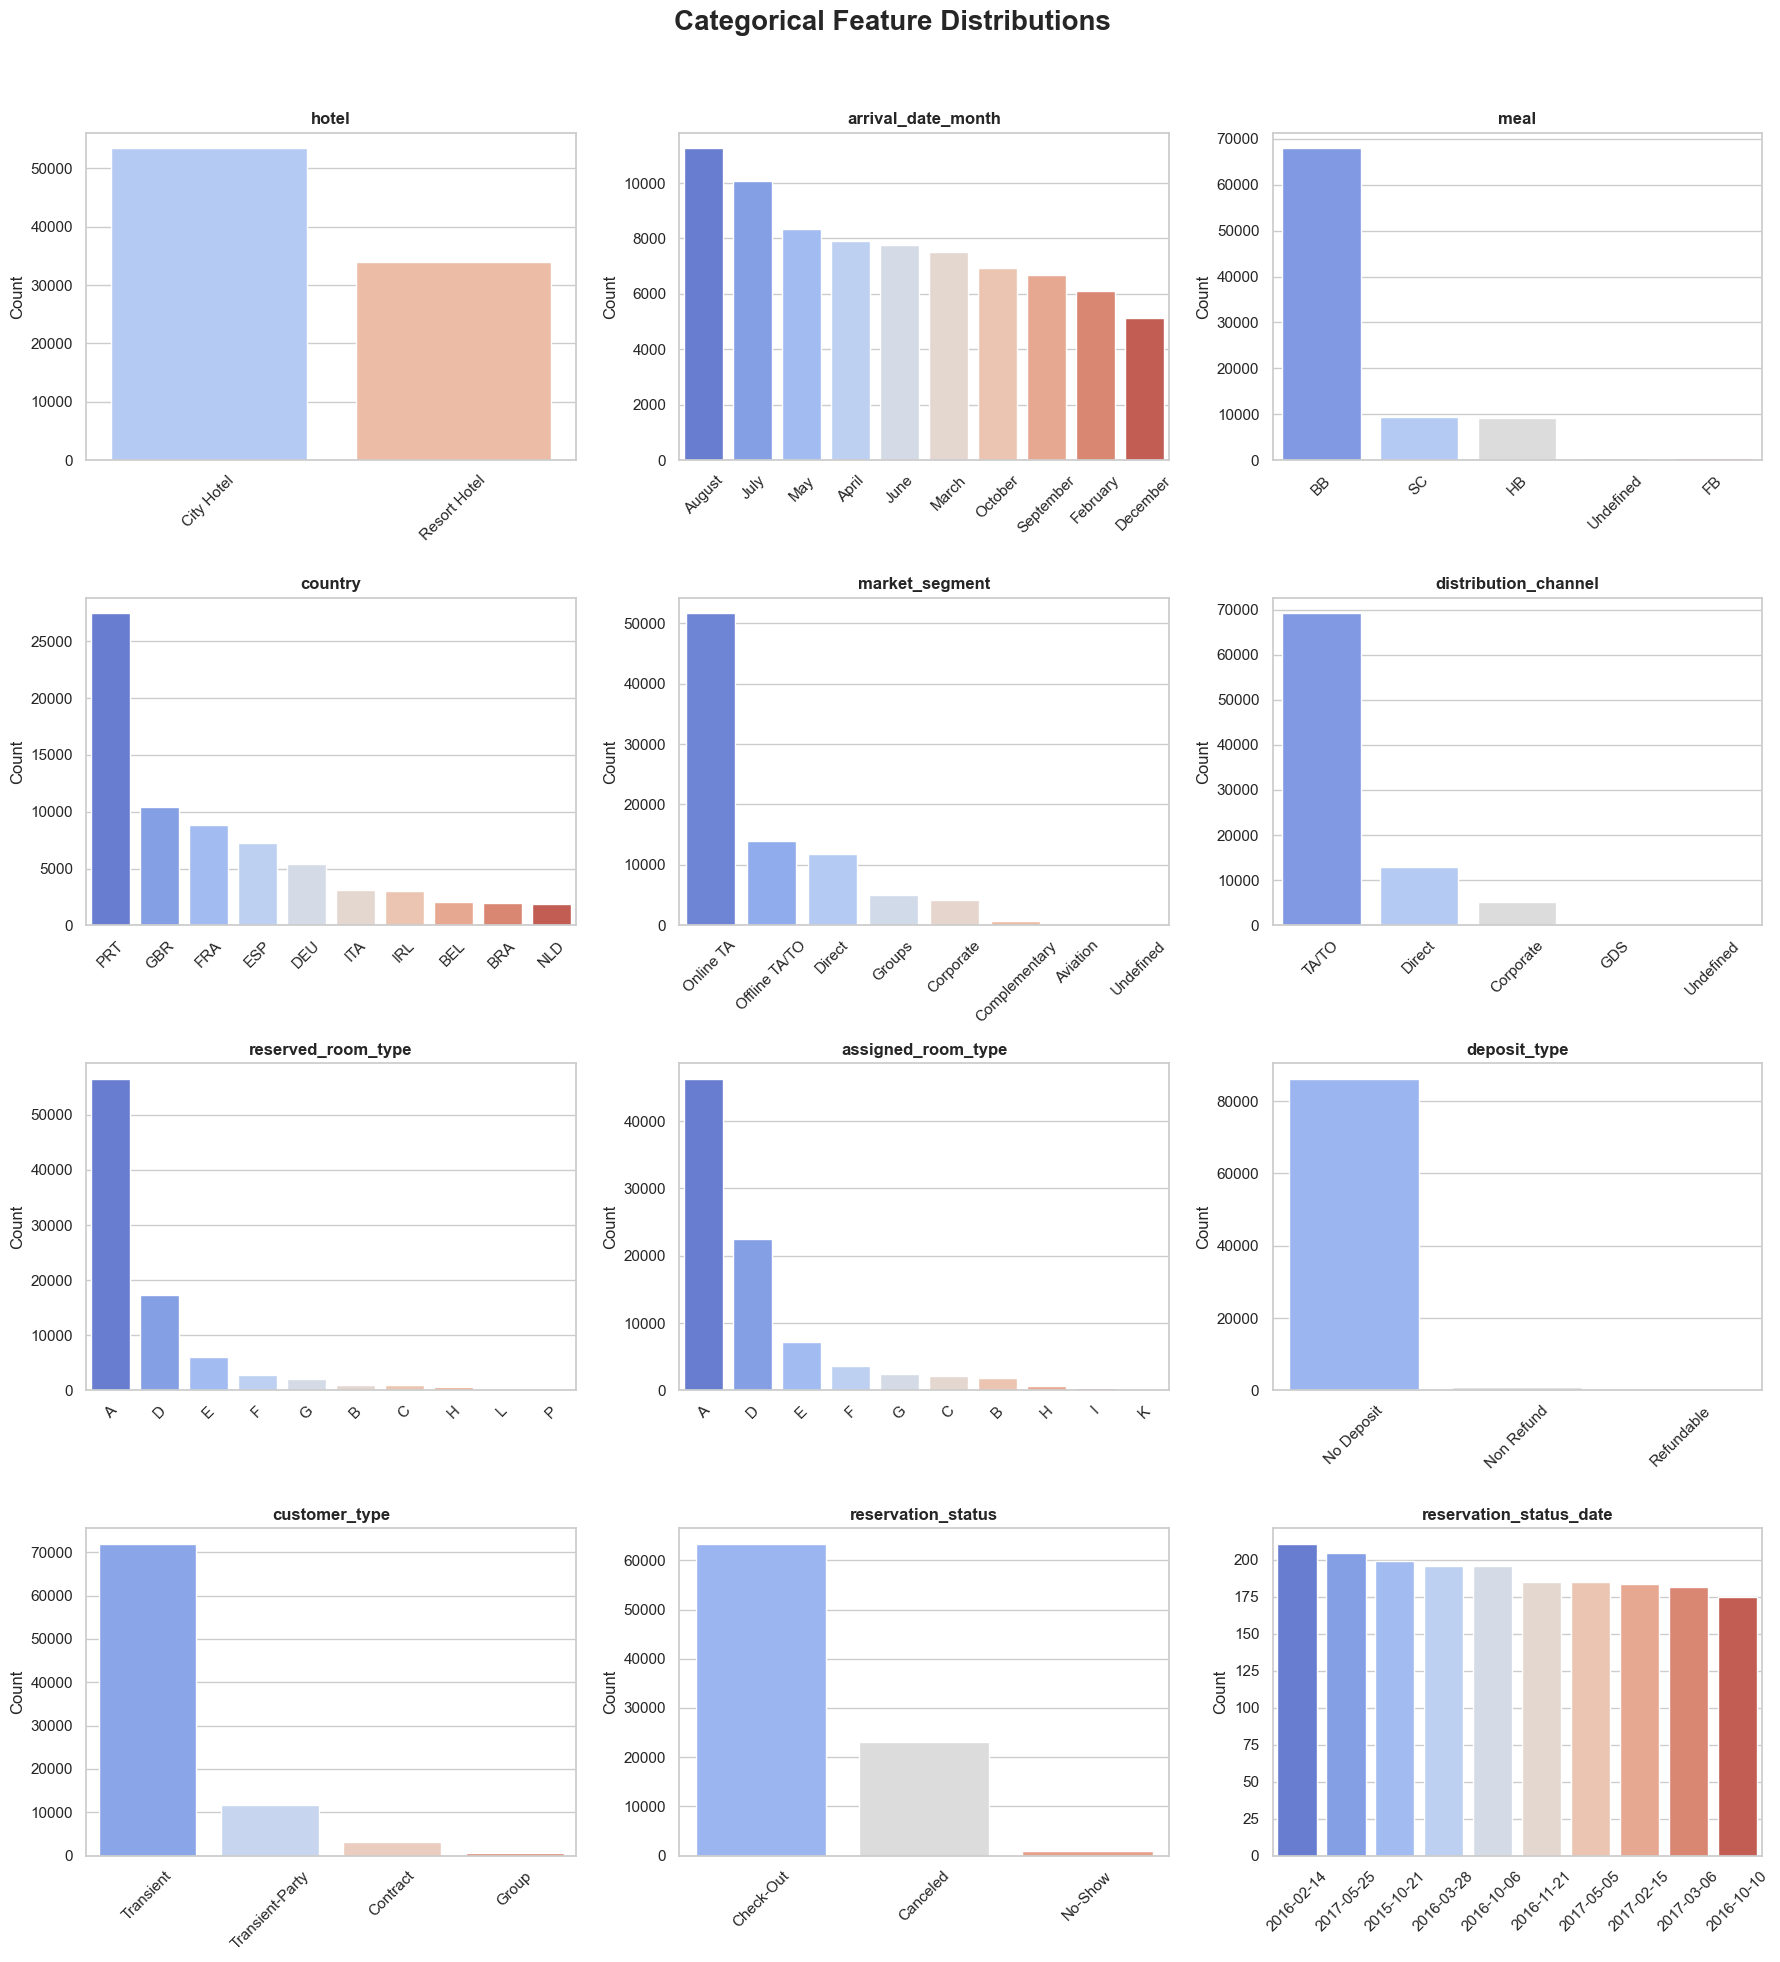

In [13]:
import math

categorical_features = df.select_dtypes(include="object").columns

n_cols = 3
n_rows = math.ceil(len(categorical_features) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(categorical_features):

    value_counts = df[col].value_counts().head(10)

    sns.barplot(
        x=value_counts.index,
        y=value_counts.values,
        hue=value_counts.index,
        palette="coolwarm",
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(col, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Categorical Feature Distributions",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

<div style="color:#ab9bde;">

## <h3>Insights:</h3>

* City Hotels dominate the dataset, accounting for substantially more bookings than Resort Hotels. This suggests that cancellation patterns and revenue risk may be driven more heavily by City Hotel customers.

* Most bookings come through Online Travel Agencies (OTA/TA), with both the market_segment and distribution_channel plots showing strong dependence on third-party booking platforms. This indicates that hotel revenue is highly influenced by external distribution partners.

* The customer base is primarily transient travelers, while contract, group, and repeat-business segments represent a much smaller share of bookings. This suggests that a large portion of demand may be more price-sensitive and potentially more prone to cancellation.

* Room Type A overwhelmingly dominates both reserved and assigned rooms, while the vast majority of bookings are made without deposits (No Deposit) and under the standard meal package (BB). This concentration indicates a relatively standardized booking profile across most customers.

</div>

### <h2 style="color: #ab9bde;">Numerical Feature Distribution</h2>

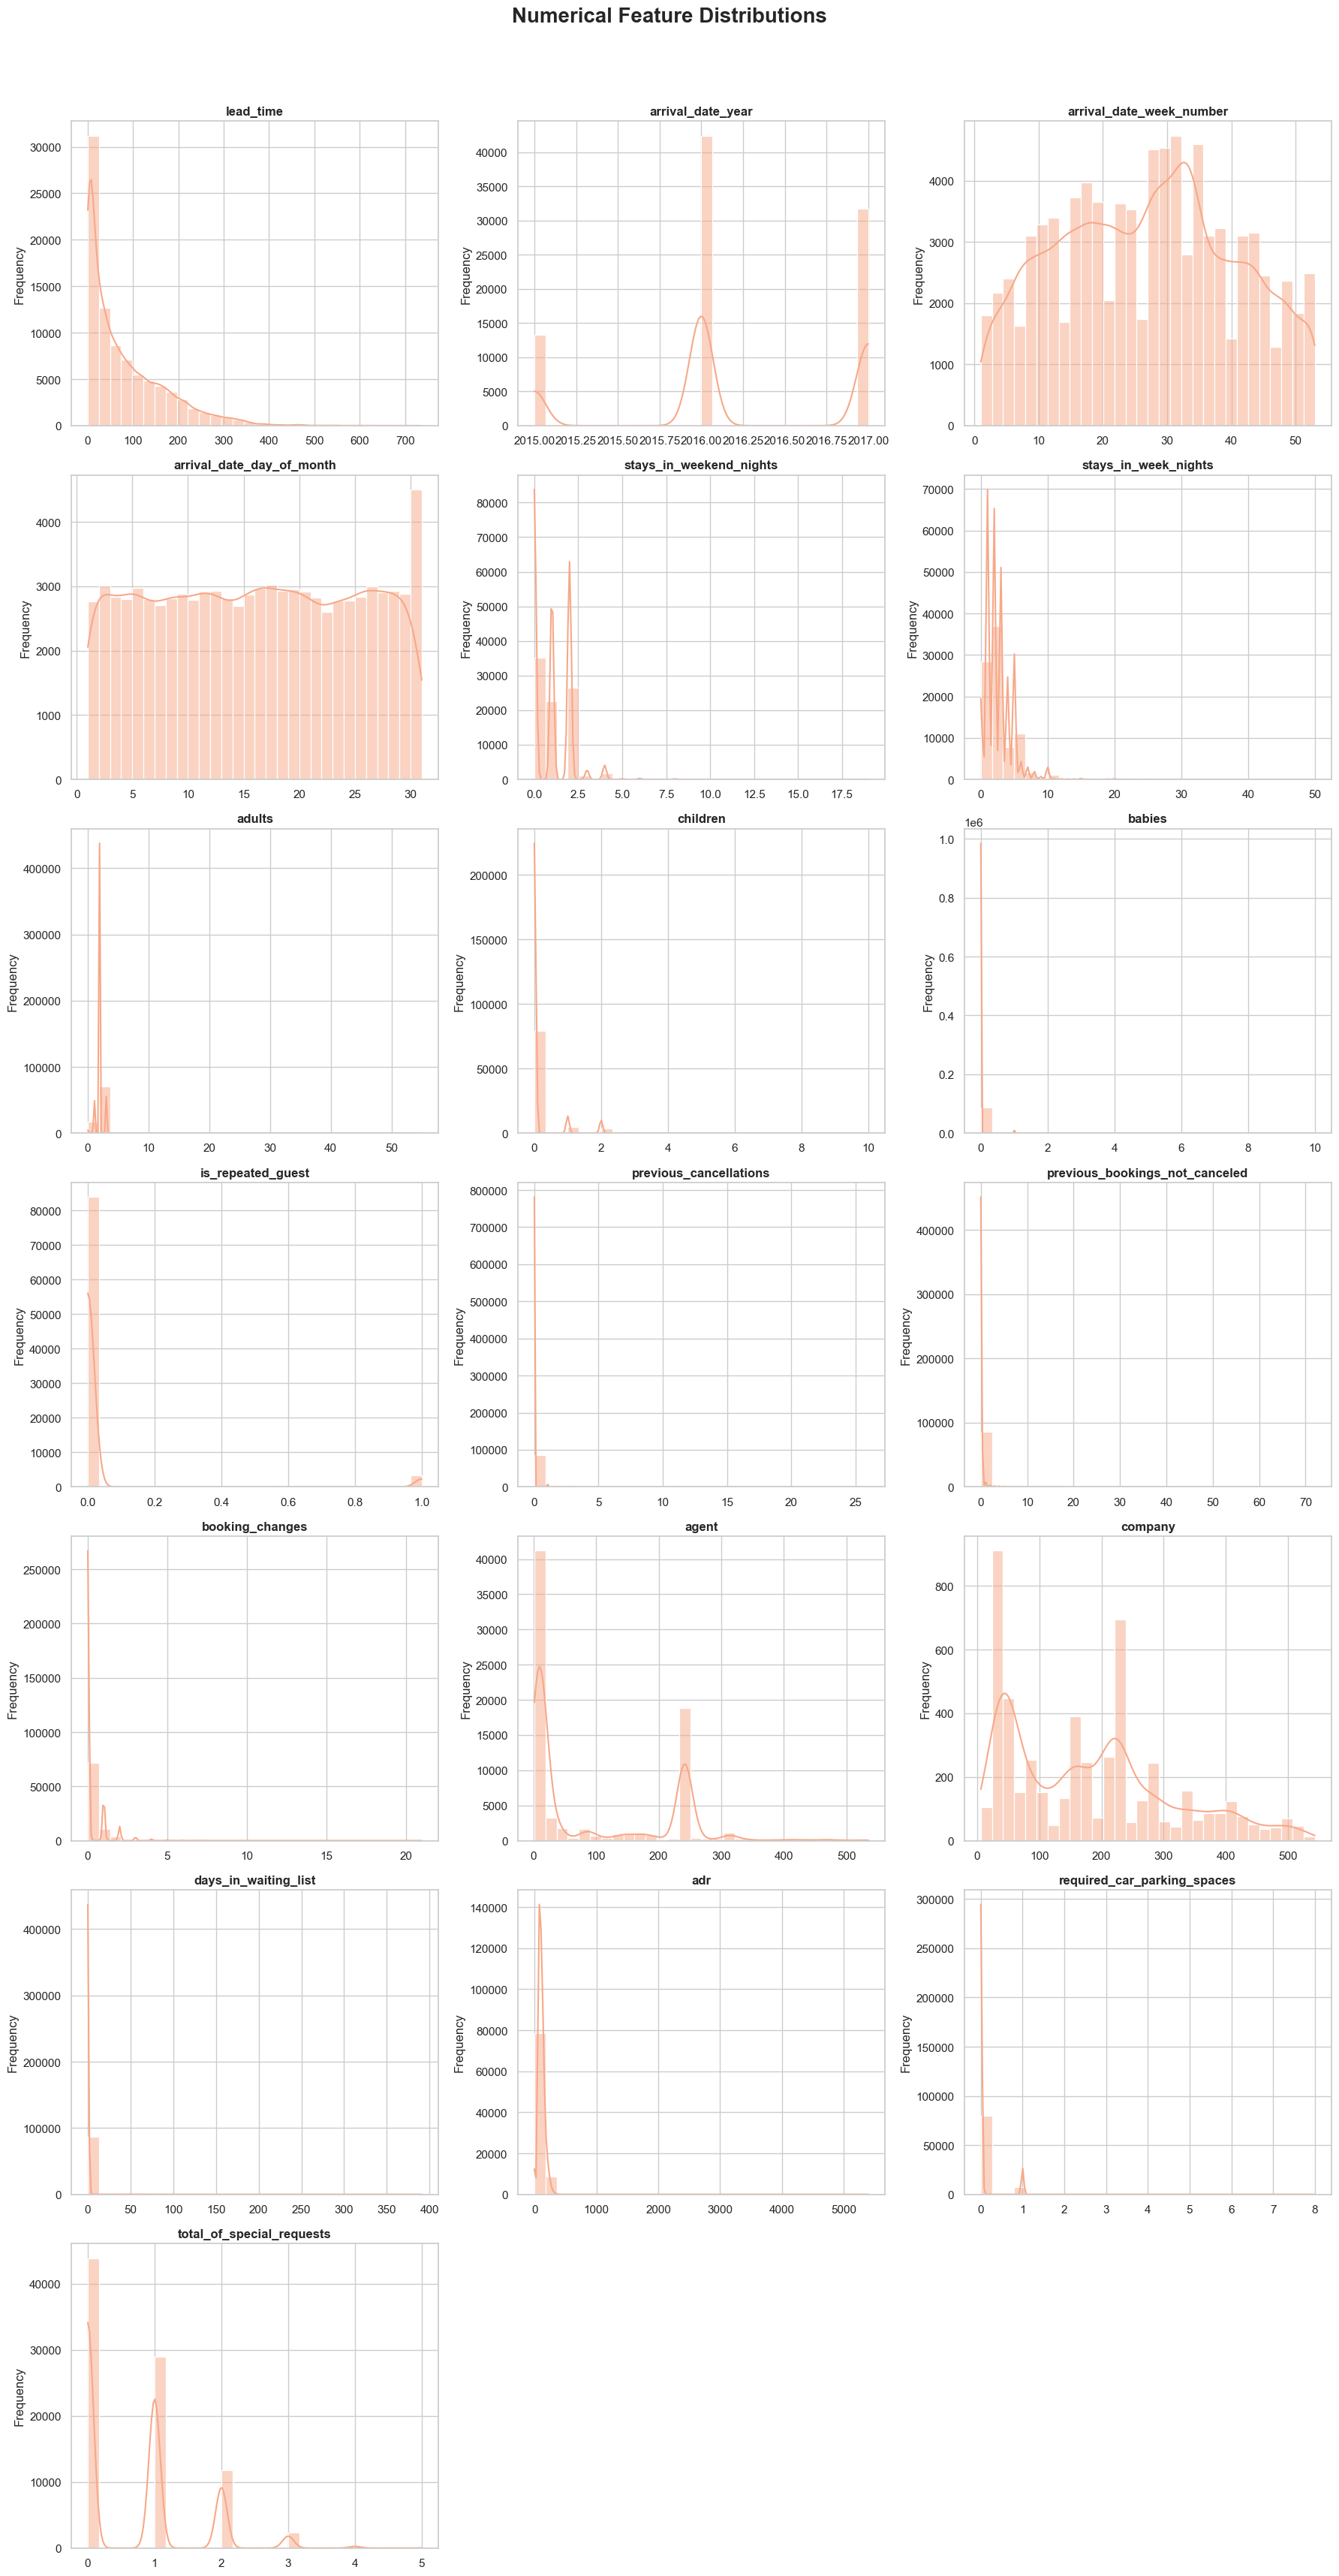

In [14]:
numerical_features = (
    df.select_dtypes(include=["int64", "float64"])
      .columns
      .drop("is_canceled", errors="ignore")
)

n_cols = 3
n_rows = math.ceil(len(numerical_features) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numerical_features):

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        color=sns.color_palette("coolwarm")[4],
        ax=axes[i]
    )

    axes[i].set_title(col, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")

# Remove unused plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Numerical Feature Distributions",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

<div style="color:#ab9bde;">

## <h3>Insights:</h3>

* Lead Time is heavily right-skewed, with most bookings made relatively close to the arrival date while a smaller group books several hundred days in advance. This suggests booking behavior varies significantly across customer types and may be an important predictor of cancellations.

* Most guests stay for short durations, with both weekday and weekend stay distributions concentrated around 1–3 nights. Extended stays are comparatively rare, indicating that the dataset is dominated by short-term hotel bookings.

* The customer mix is overwhelmingly composed of small travel parties, typically 1–2 adults with very few children or babies. Large family bookings are uncommon and may represent a distinct customer segment.

* Average Daily Rate (ADR) exhibits strong positive skewness, with a small number of extremely high-priced bookings. This indicates the presence of premium reservations that could create disproportionate revenue impact if cancelled.

</div>

### <h3 style="color: #ab9bde;">Save Cleaned Dataset</h3>

In [16]:
df.to_csv(
    "../data/hotel_bookings_clean.csv",
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.
